**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Exploración y Curación de Datos**

*Edición 2026*

----

# Trabajo práctico entregable - parte 2

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [ ]:
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn as sns
sns.set_context('talk')
from IPython.display import display
from sqlalchemy import create_engine, text
from google.colab import drive
import os

In [ ]:
import plotly
plotly.__version__


'5.24.1'

In [ ]:
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar. Usá `df.dtypes` para ver los tipos actuales. Prestá especial atención a columnas como `Date` y `Price`: por ejemplo, `Date` puede estar como string en vez de datetime, y `Price` puede venir como string o float. El método `to_sql()` infiere tipos automáticamente, pero puede fallar si los tipos no son los esperados.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por `Regionname`.
    - cantidad de registros totales por `Suburb` y `Regionname`.
    - Consulta con filtro: ¿Cuántas propiedades hay por `Regionname` con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (`Type`) y `Regionname`?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL para obtener un resultado similar a lo realizado con Pandas en clase.

6. Agregar una celda de validación posterior al JOIN con assertions o validación de esquema. Como mínimo, verificá que el número de filas no cambió, que no aparecieron nulos inesperados y que los rangos de variables agregadas sean razonables. Esta validación implementa dimensiones básicas de calidad de datos como validez, completitud e integridad.



In [ ]:
# 1. Creación de la base de datos SQLite utilizando SQLAlchemy

# Creamos el motor de conexión a una base SQLite local.
engine = create_engine('sqlite:///diplodatos.sqlite', echo=False)

print("Base de datos SQLite creada correctamente.")

Base de datos SQLite creada correctamente.


In [ ]:
# 2. Ingesta de los datos

# El dataset de Melbourne

url_melb = 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv'

melb_df = pd.read_csv(url_melb)

print("Dataset de Melbourne cargado correctamente.")
print(f"Dimensiones: {melb_df.shape}")

display(melb_df.head())

Dataset de Melbourne cargado correctamente.
Dimensiones: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Definimos la ruta del dataset de Airbnb y verificamos que exista



In [ ]:
# Ingestar el dataset de Airbnb

ruta_airbnb = '/content/drive/MyDrive/Análisis Exploratorio y Curación de Datos/airbnb_price_by_zipcode.csv'
airbnb_df = pd.read_csv(ruta_airbnb)
print("Dataset de Airbnb cargado correctamente.")
print(f"Dimensiones: {airbnb_df.shape}")

display(airbnb_df.head())

Dataset de Airbnb cargado correctamente.
Dimensiones: (247, 5)


,zipcode,airbnb_price_mean,airbnb_record_count,airbnb_weekly_price_mean,airbnb_monthly_price_mean
0,2010.0,40.000000,1,NaN,NaN
1,2134.0,50.000000,1,NaN,NaN
2,2582.0,104.000000,1,NaN,NaN
3,3000.0,150.504307,3367,918.738956,3407.204651
4,3001.0,132.500000,2,NaN,NaN


In [ ]:
# 3. Validar tipos de columnas antes de guardar en SQLite

print("Tipos originales de columnas clave en Melbourne:")
print(melb_df[['Date', 'Price', 'Postcode']].dtypes)

print("\nTipos originales de columnas clave en Airbnb:")
print(airbnb_df[['zipcode', 'airbnb_price_mean', 'airbnb_record_count']].dtypes)

Tipos originales de columnas clave en Melbourne:
Date         object
Price       float64
Postcode    float64
dtype: object

Tipos originales de columnas clave en Airbnb:
zipcode                float64
airbnb_price_mean      float64
airbnb_record_count      int64
dtype: object


In [ ]:
# Corrección de tipos en Melbourne

melb_df['Date'] = pd.to_datetime(
    melb_df['Date'],
    format='%d/%m/%Y',
    errors='coerce')

melb_df['Price'] = pd.to_numeric(
    melb_df['Price'],
    errors='coerce')

melb_df['Postcode'] = pd.to_numeric(
    melb_df['Postcode'],
    errors='coerce')

# Corrección de tipos en Airbnb

airbnb_df['zipcode'] = pd.to_numeric(
    airbnb_df['zipcode'],
    errors='coerce')

airbnb_df['airbnb_price_mean'] = pd.to_numeric(
    airbnb_df['airbnb_price_mean'],
    errors='coerce')

airbnb_df['airbnb_record_count'] = pd.to_numeric(
    airbnb_df['airbnb_record_count'],
    errors='coerce')

print("Tipos corregidos de columnas clave en Melbourne:")
print(melb_df[['Date', 'Price', 'Postcode']].dtypes)

print("\nTipos corregidos de columnas clave en Airbnb:")
print(airbnb_df[['zipcode', 'airbnb_price_mean', 'airbnb_record_count']].dtypes)

Tipos corregidos de columnas clave en Melbourne:
Date        datetime64[ns]
Price              float64
Postcode           float64
dtype: object

Tipos corregidos de columnas clave en Airbnb:
zipcode                float64
airbnb_price_mean      float64
airbnb_record_count      int64
dtype: object


In [ ]:
# Validaciones posteriores a la corrección de tipos

assert melb_df['Date'].notna().all(), \
    "Existen fechas que no pudieron convertirse correctamente."

assert melb_df['Price'].notna().all(), \
    "Existen precios nulos o no numéricos en Melbourne."

assert melb_df['Postcode'].notna().all(), \
    "Existen códigos postales nulos o no numéricos en Melbourne."

assert airbnb_df['zipcode'].notna().all(), \
    "Existen zipcodes nulos o no numéricos en Airbnb."

assert airbnb_df['airbnb_price_mean'].notna().all(), \
    "Existen precios promedio nulos o no numéricos en Airbnb."

assert airbnb_df['airbnb_record_count'].notna().all(), \
    "Existen cantidades de registros nulas o no numéricas en Airbnb."

print("Validaciones de tipos superadas.")

Validaciones de tipos superadas.


In [ ]:
# 4. Guardar los datasets como tablas en SQLite

melb_df.to_sql(
    'melbourne',
    con=engine,
    if_exists='replace',
    index=False)

airbnb_df.to_sql(
    'airbnb',
    con=engine,
    if_exists='replace',
    index=False)

print("Tablas guardadas correctamente en SQLite.")

Tablas guardadas correctamente en SQLite.


In [ ]:
# 5. Consultas SQL:

# Consulta 1: cantidad de registros por región

query_1 = """
SELECT
    Regionname,
    COUNT(*) AS total_registros
FROM melbourne
GROUP BY Regionname
ORDER BY total_registros DESC;
"""

resultado_1 = pd.read_sql_query(query_1, con=engine)

display(resultado_1)

,Regionname,total_registros
0,Southern Metropolitan,4695
1,Northern Metropolitan,3890
2,Western Metropolitan,2948
3,Eastern Metropolitan,1471
4,South-Eastern Metropolitan,450
5,Eastern Victoria,53
6,Northern Victoria,41
7,Western Victoria,32


La consulta muestra la cantidad de propiedades registradas en cada región. Se observa que `Southern Metropolitan` es la región con mayor representación dentro del dataset.

In [ ]:
# Consulta 2: cantidad de registros por región y suburbio

query_2 = """
SELECT
    Regionname,
    Suburb,
    COUNT(*) AS total_registros
FROM melbourne
GROUP BY Regionname, Suburb
ORDER BY Regionname, total_registros DESC;
"""

resultado_2 = pd.read_sql_query(query_2, con=engine)

display(resultado_2)

,Regionname,Suburb,total_registros
0,Eastern Metropolitan,Doncaster,116
1,Eastern Metropolitan,Ivanhoe,98
2,Eastern Metropolitan,Templestowe Lower,92
3,Eastern Metropolitan,Heidelberg Heights,78
4,Eastern Metropolitan,Heidelberg West,76
...,...,...,...
309,Western Metropolitan,Plumpton,1
310,Western Victoria,Melton South,18
311,Western Victoria,Melton,12
312,Western Victoria,Brookfield,1


La consulta muestra la cantidad de propiedades por región y suburbio. Por ejemplo, dentro de `Eastern Metropolitan`, `Doncaster` es el suburbio con mayor cantidad de registros.

In [ ]:
# Consulta 3: cantidad de propiedades con más de dos habitaciones por región

query_3 = """
SELECT
    Regionname,
    COUNT(*) AS propiedades_mas_2_habitaciones
FROM melbourne
WHERE Rooms > 2
GROUP BY Regionname
ORDER BY propiedades_mas_2_habitaciones DESC;
"""

resultado_3 = pd.read_sql_query(query_3, con=engine)

display(resultado_3)

,Regionname,propiedades_mas_2_habitaciones
0,Southern Metropolitan,2848
1,Northern Metropolitan,2389
2,Western Metropolitan,2259
3,Eastern Metropolitan,1228
4,South-Eastern Metropolitan,407
5,Eastern Victoria,50
6,Northern Victoria,39
7,Western Victoria,31


La consulta muestra las propiedades con más de dos habitaciones por región. `Southern Metropolitan` es la región con mayor cantidad de propiedades de este tipo dentro del dataset.

In [ ]:
# Consulta 4: precio promedio por región y tipo de propiedad

query_4 = """
SELECT
    Regionname,
    Type,
    AVG(Price) AS precio_promedio
FROM melbourne
GROUP BY Regionname, Type
ORDER BY Regionname, Type;
"""

resultado_4 = pd.read_sql_query(query_4, con=engine)

display(resultado_4)

,Regionname,Type,precio_promedio
0,Eastern Metropolitan,h,1.197450e+06
1,Eastern Metropolitan,t,8.696199e+05
2,Eastern Metropolitan,u,6.493144e+05
3,Eastern Victoria,h,7.142996e+05
4,Eastern Victoria,u,4.613333e+05
5,Northern Metropolitan,h,1.021222e+06
6,Northern Metropolitan,t,7.496083e+05
7,Northern Metropolitan,u,5.444038e+05
8,Northern Victoria,h,5.948293e+05
9,South-Eastern Metropolitan,h,9.559496e+05


La consulta calcula el precio promedio de las propiedades según región y tipo de inmueble. Esto nos permite comparar diferencias de precio entre zonas y tipologías de propiedad.

En los primeros resultados se observa que, dentro de `Eastern Metropolitan`, las casas (`h`) tienen un precio promedio superior al de las unidades (`u`) y townhouses (`t`).




In [ ]:
# Consulta 5: cinco suburbios con mayor precio promedio

query_5 = """
SELECT
    Suburb,
    COUNT(*) AS cantidad_propiedades,
    AVG(Price) AS precio_promedio
FROM melbourne
GROUP BY Suburb
ORDER BY precio_promedio DESC
LIMIT 5;
"""

resultado_5 = pd.read_sql_query(query_5, con=engine)

display(resultado_5)

,Suburb,cantidad_propiedades,precio_promedio
0,Kooyong,2,2.185000e+06
1,Canterbury,54,2.180241e+06
2,Middle Park,34,2.082529e+06
3,Albert Park,69,1.941355e+06
4,Brighton,186,1.930158e+06


La consulta identifica los cinco suburbios con mayor precio promedio. `Kooyong` aparece en primer lugar, aunque el promedio se calcula sobre solo 2 propiedades, por lo que debe interpretarse con cautela. `Brighton`, en cambio, tiene un precio promedio alto con 186 registros, lo que lo vuelve más representativo dentro del resultado.

In [ ]:
# 5. Primero leemos las tablas desde SQLite para validar antes del JOIN

melb_original = pd.read_sql_query(
    "SELECT * FROM melbourne;",
    con=engine
)

airbnb_original = pd.read_sql_query(
    "SELECT * FROM airbnb;",
    con=engine
)

print("Dimensiones de melbourne:", melb_original.shape)
print("Dimensiones de airbnb:", airbnb_original.shape)

Dimensiones de melbourne: (13580, 21)
Dimensiones de airbnb: (247, 5)


In [ ]:
# Validamos que zipcode sea único en Airbnb

duplicados_zipcode = airbnb_original['zipcode'].duplicated().sum()

assert duplicados_zipcode == 0, \
    f"Hay {duplicados_zipcode} zipcodes duplicados en Airbnb. El JOIN podría duplicar filas."

print("Validación superada: no hay zipcodes duplicados en Airbnb.")

Validación superada: no hay zipcodes duplicados en Airbnb.


In [ ]:
# JOIN entre Melbourne y Airbnb mediante código postal

query_join = """
SELECT
    m.*,
    a.airbnb_price_mean,
    a.airbnb_record_count,
    a.airbnb_weekly_price_mean,
    a.airbnb_monthly_price_mean
FROM melbourne AS m
LEFT JOIN airbnb AS a
ON m.Postcode = a.zipcode;
"""

melb_joined_df = pd.read_sql_query(query_join, con=engine)

print("Dimensiones del dataset luego del JOIN:")
print(melb_joined_df.shape)

display(melb_joined_df.head())

Dimensiones del dataset luego del JOIN:
(13580, 25)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,airbnb_price_mean,airbnb_record_count,airbnb_weekly_price_mean,airbnb_monthly_price_mean
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03 00:00:00.000000,2.5,3067.0,...,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,130.624031,258.0,605.152174,2187.032258
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04 00:00:00.000000,2.5,3067.0,...,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,130.624031,258.0,605.152174,2187.032258
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04 00:00:00.000000,2.5,3067.0,...,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,130.624031,258.0,605.152174,2187.032258
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04 00:00:00.000000,2.5,3067.0,...,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,130.624031,258.0,605.152174,2187.032258
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04 00:00:00.000000,2.5,3067.0,...,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,130.624031,258.0,605.152174,2187.032258


El resultado del `LEFT JOIN` conserva todas las columnas de la tabla `melbourne` y agrega las variables disponibles de Airbnb asociadas al mismo código postal. Las propiedades ubicadas en códigos postales sin información de Airbnb quedan con valores faltantes en las columnas agregadas.

In [ ]:
# 6. Validaciones posteriores al JOIN

Luego de realizar la unión entre las tablas `melbourne` y `airbnb`, se aplican controles para verificar que el proceso de integración no haya alterado indebidamente el dataset base. En particular, se valida que la cantidad de filas se mantenga igual a la tabla original de Melbourne, que las columnas críticas no hayan modificado su cantidad de valores faltantes y que las variables incorporadas desde Airbnb presenten valores razonables.

Estas validaciones son importantes porque un `JOIN` mal definido puede duplicar registros, eliminar observaciones o incorporar datos inconsistentes.

In [ ]:
# Validación 1: el JOIN no debe modificar la cantidad de filas de Melbourne

assert len(melb_joined_df) == len(melb_original), \
    "El JOIN modificó la cantidad de filas del dataset de Melbourne."

print("Validación exitosa! El JOIN conserva la cantidad de filas de Melbourne.")
print(f"Filas en Melbourne original: {len(melb_original)}")
print(f"Filas luego del JOIN: {len(melb_joined_df)}")

Validación exitosa! El JOIN conserva la cantidad de filas de Melbourne.
Filas en Melbourne original: 13580
Filas luego del JOIN: 13580


In [ ]:
# Validación 2: el JOIN no debe modificar la cantidad de nulos en columnas críticas

columnas_criticas = ['Suburb', 'Rooms', 'Price', 'Postcode', 'Regionname']

for col in columnas_criticas:
    nulos_original = melb_original[col].isna().sum()
    nulos_joined = melb_joined_df[col].isna().sum()

    assert nulos_original == nulos_joined, \
        f"Se modificó la cantidad de nulos en la columna {col}."

print("Validación exitosa!las columnas críticas de Melbourne mantienen la misma cantidad de nulos.")

Validación exitosa!las columnas críticas de Melbourne mantienen la misma cantidad de nulos.


In [ ]:
# Validación 3: las variables agregadas de Airbnb deben tener valores razonables

assert (melb_joined_df['airbnb_price_mean'].dropna() >= 0).all(), \
    "Hay valores negativos en airbnb_price_mean."

assert (melb_joined_df['airbnb_record_count'].dropna() >= 0).all(), \
    "Hay valores negativos en airbnb_record_count."

assert (melb_joined_df['airbnb_weekly_price_mean'].dropna() >= 0).all(), \
    "Hay valores negativos en airbnb_weekly_price_mean."

assert (melb_joined_df['airbnb_monthly_price_mean'].dropna() >= 0).all(), \
    "Hay valores negativos en airbnb_monthly_price_mean."

print("Validación exitosa! las variables agregadas de Airbnb presentan valores no negativos.")

Validación exitosa! las variables agregadas de Airbnb presentan valores no negativos.


In [ ]:
propiedades_con_airbnb = melb_joined_df['airbnb_price_mean'].notna().sum()
total_propiedades = len(melb_joined_df)
porcentaje_match = propiedades_con_airbnb / total_propiedades * 100

print(f"Total de propiedades Melbourne: {total_propiedades}")
print(f"Propiedades con información Airbnb agregada: {propiedades_con_airbnb}")
print(f"Porcentaje de propiedades con información Airbnb: {porcentaje_match:.2f}%")

Total de propiedades Melbourne: 13580
Propiedades con información Airbnb agregada: 13560
Porcentaje de propiedades con información Airbnb: 99.85%


Las validaciones posteriores al `JOIN` muestran que la unión no modificó la cantidad de registros del dataset base ni alteró columnas críticas de Melbourne. Esto indica que la integración fue realizada correctamente y que no se generaron duplicaciones o pérdidas de observaciones.

Las variables agregadas de Airbnb también presentan valores no negativos, lo cual es consistente con su interpretación como precios promedio y cantidad de registros. Finalmente, el porcentaje de propiedades con información Airbnb permite evaluar la cobertura de la fuente externa incorporada. Las propiedades sin coincidencia por código postal conservan valores faltantes en las columnas de Airbnb, lo cual es esperable al utilizar un `LEFT JOIN`.



---



## Ejercicio 2 - Pandas:

Este ejercicio usa el archivo `airbnb_price_by_zipcode.csv` generado en el notebook `02.1 Combinación de datasets.ipynb`. Si no lo tenés, generarlo primero antes de comenzar esta parte.

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2. Mostrar la dispersión o distribución de las columnas seleccionadas.
 3. Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás


2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (¿por qué no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación. Si tuvieras que entrevistar a un experto inmobiliario para mapear barrios entre datasets, ¿qué 3 preguntas le harías para validar esa correspondencia?
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?


### Criterios de evaluación
Se evaluará principalmente:
- claridad del código,
- justificación de las decisiones de curación,
- coherencia entre el análisis realizado y las conclusiones,
- presencia de validaciones después de operaciones críticas como merges o cargas a base.

No se espera una única solución correcta, pero sí que las decisiones estén justificadas y sean consistentes con los datos.


In [ ]:
#1. Seleccionamos las columnas relevantes para el análisis
columnas_relevantes = [
    'Suburb', 'Rooms', 'Type', 'Price', 'Distance', 'Postcode',
    'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt',
    'Lattitude', 'Longtitude', 'Regionname'
]

# Filtramos el dataframe original quedándonos solo con lo que nos importa
melb_df_curado = melb_df[columnas_relevantes].copy()

Se seleccionaron variables que pueden explicar el valor de una propiedad desde tres dimensiones principales: características físicas, localización y tipo de inmueble.

Las variables `Rooms`, `Bathroom`, `Car`, `Landsize`, `BuildingArea` y `YearBuilt` representan atributos propios de la vivienda.

Las variables `Suburb`, `Postcode`, `Regionname`, `Distance`, `Lattitude` y `Longtitude` capturan información geográfica y de entorno, relevante en la formación de precios inmobiliarios.

La variable `Type` permite distinguir entre casas, departamentos y otras tipologías, mientras que `Price` se conserva como variable objetivo del análisis.

In [ ]:
# 2. Valores faltantes: Calculamos cuántas filas tienen al menos un NaN (nulo)
filas_con_nulos = melb_df_curado.isnull().any(axis=1).sum()
total_filas = len(melb_df_curado)
porcentaje_faltantes = (filas_con_nulos / total_filas) * 100

print(f"Total de propiedades en el dataset: {total_filas}")
print(f"Propiedades con al menos un dato faltante: {filas_con_nulos}")
print(f"Porcentaje de filas con datos faltantes: {porcentaje_faltantes:.2f}%")

Total de propiedades en el dataset: 13580
Propiedades con al menos un dato faltante: 6750
Porcentaje de filas con datos faltantes: 49.71%


In [ ]:
missing_by_col = (
    melb_df_curado
    .isnull()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("Porcentaje de valores faltantes por columna:")
display(missing_by_col)

Porcentaje de valores faltantes por columna:


,0
BuildingArea,47.50
YearBuilt,39.58
Car,0.46
Type,0.00
Suburb,0.00
Rooms,0.00
Postcode,0.00
Distance,0.00
Price,0.00
Bathroom,0.00


El porcentaje de filas con al menos un valor faltante es elevado, aproximadamente 49.71%. Sin embargo, esto no implica necesariamente que deban eliminarse todas esas observaciones, ya que los faltantes pueden estar concentrados en algunas variables específicas. Por ese motivo, se analiza también el porcentaje de faltantes por columna antes de decidir una estrategia de imputación o eliminación.

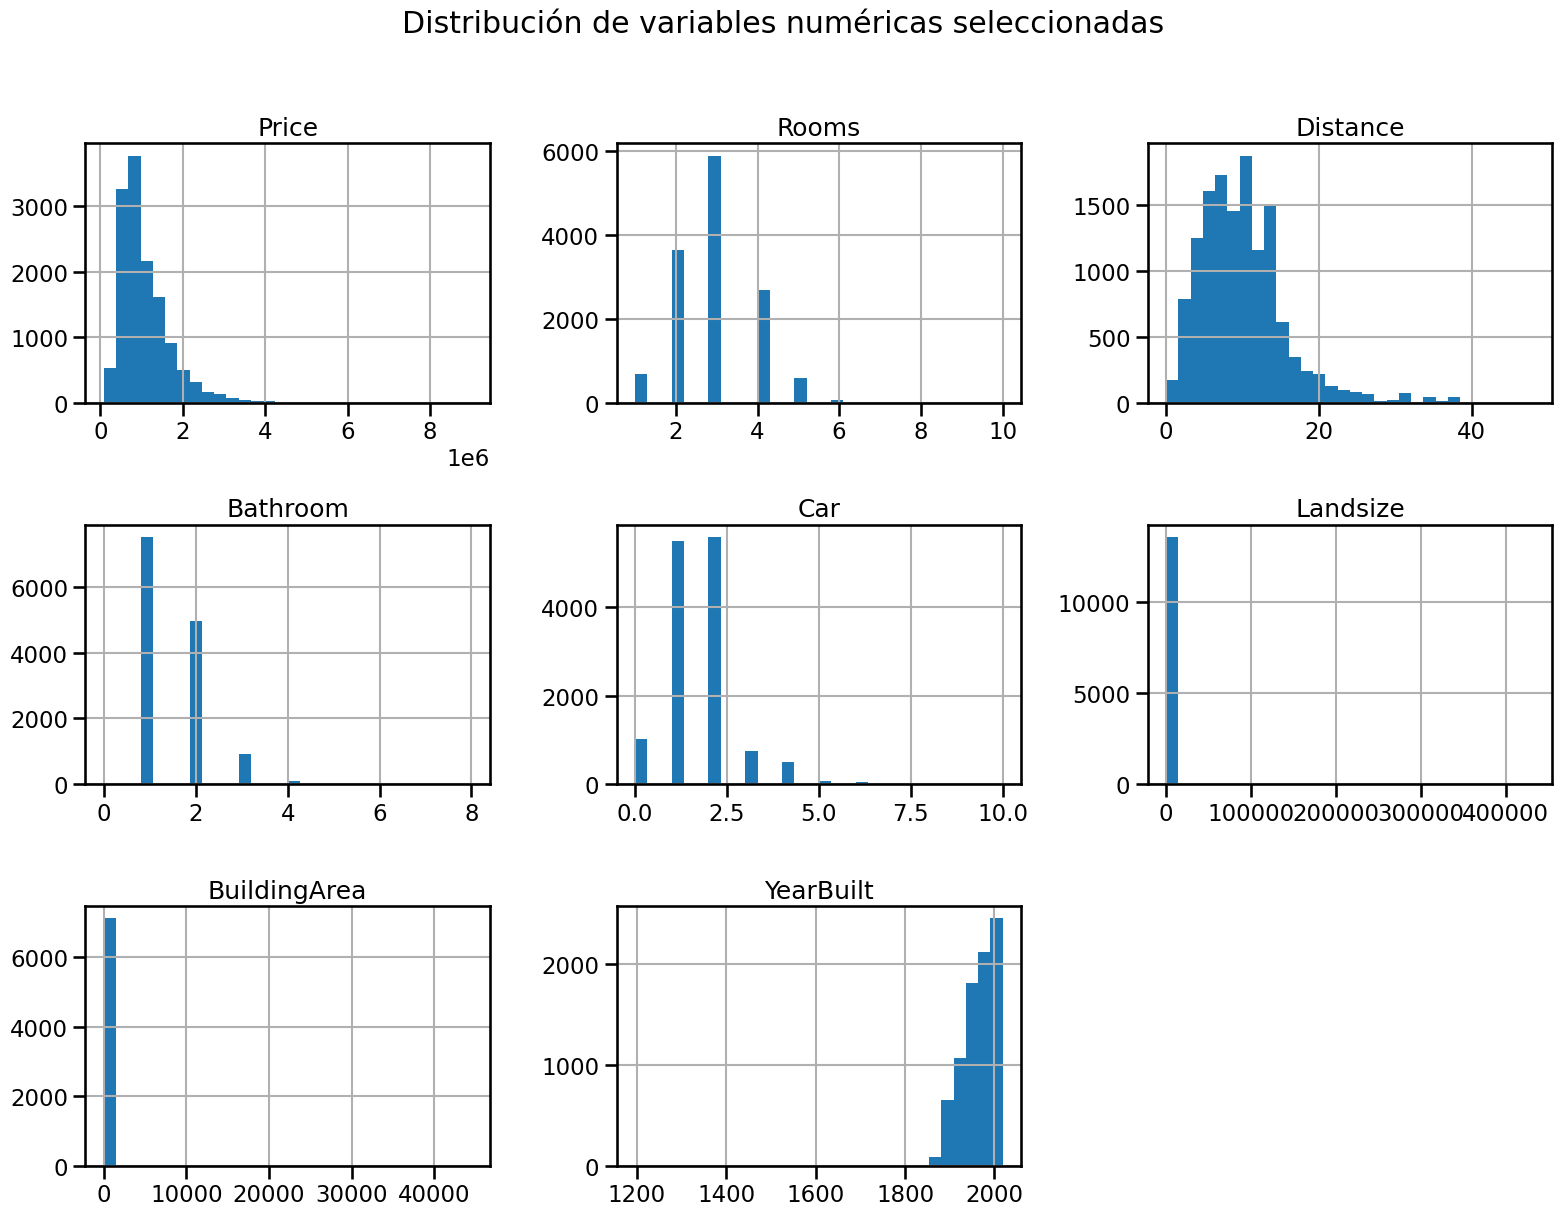

In [ ]:
# 3. Variables numéricas seleccionadas para analizar distribución
columnas_numericas = [
    'Price', 'Rooms', 'Distance', 'Bathroom', 'Car',
    'Landsize', 'BuildingArea', 'YearBuilt'
]

melb_df_curado[columnas_numericas].hist(figsize=(16, 12), bins=30)
plt.suptitle('Distribución de variables numéricas seleccionadas', y=1.02)
plt.tight_layout()
plt.show()

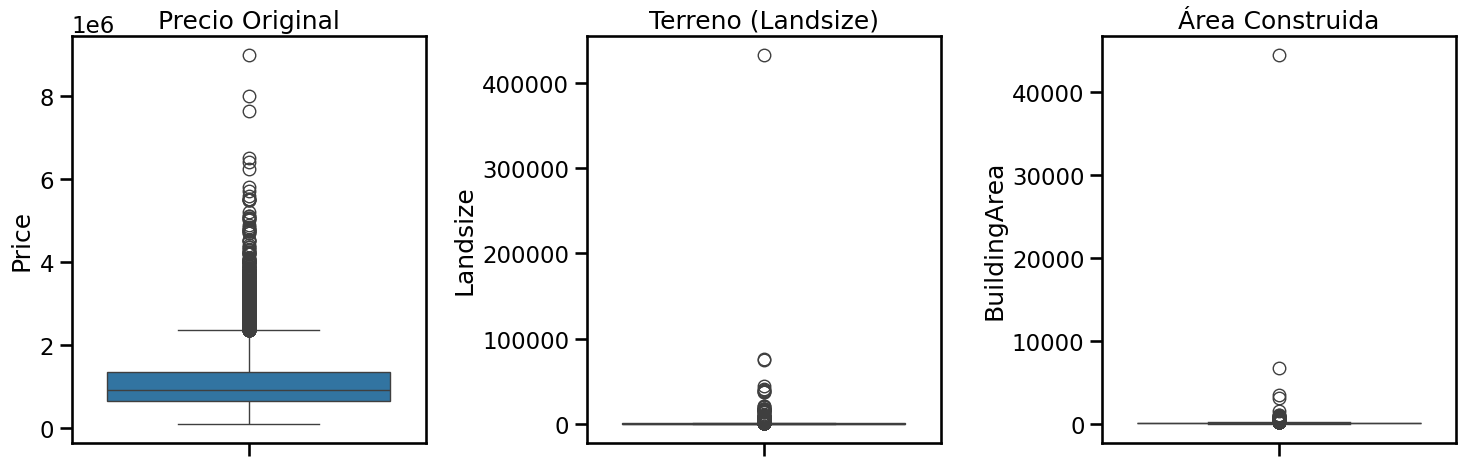

In [ ]:
# Mostrar la dispersión/distribución ANTES de limpiar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=melb_df_curado['Price'], ax=axes[0]).set_title('Precio Original')
sns.boxplot(y=melb_df_curado['Landsize'], ax=axes[1]).set_title('Terreno (Landsize)')
sns.boxplot(y=melb_df_curado['BuildingArea'], ax=axes[2]).set_title('Área Construida')
plt.tight_layout()
plt.show()

Se observa que algunas variables numéricas presentan una dispersión muy elevada, especialmente `Price`, `Landsize` y `BuildingArea`. Estas variables pueden contener observaciones extremas asociadas a propiedades muy atípicas, errores de carga o inmuebles que no son representativos del mercado residencial general que se busca analizar.

In [ ]:
# 4. y 5. Eliminación y visualización de valores extremos

# Primero definimos criterios para identificar valores extremos

# Para Price se utiliza un criterio relativo: percentil 99.
limite_precio = melb_df_curado['Price'].quantile(0.99)

# Para Landsize y BuildingArea se utilizan umbrales absolutos.
limite_terreno = 5000
limite_construccion = 1000

print(f"Límite superior para Price, percentil 99: {limite_precio:,.2f}")
print(f"Límite superior para Landsize: {limite_terreno}")
print(f"Límite superior para BuildingArea: {limite_construccion}")

Límite superior para Price, percentil 99: 3,338,150.00
Límite superior para Landsize: 5000
Límite superior para BuildingArea: 1000


Para reducir la influencia de estos valores extremos sobre el análisis posterior, se definieron criterios de filtrado sobre dichas variables. En el caso de `Price`, se eliminó el 1% superior de los valores, utilizando el percentil 99 como umbral. Para `Landsize` y `BuildingArea`, se establecieron umbrales absolutos de 5000 m² y 1000 m² respectivamente, dado que valores superiores pueden corresponder a propiedades poco comparables con el resto del dataset o posibles errores de registro.

Es importante aclarar que los valores faltantes en `Landsize` y `BuildingArea` se conservaron, ya que la ausencia de información no implica necesariamente que la observación sea inválida. La decisión busca obtener un dataset más robusto para el análisis exploratorio y las etapas posteriores de modelado, sin eliminar registros únicamente por contener datos faltantes.

In [ ]:
# Identificación de observaciones que cumplen con los criterios definidos

condicion_no_outlier = (
    (melb_df_curado['Price'] <= limite_precio) &
    ((melb_df_curado['Landsize'] <= limite_terreno) | (melb_df_curado['Landsize'].isna())) &
    ((melb_df_curado['BuildingArea'] <= limite_construccion) | (melb_df_curado['BuildingArea'].isna()))
)

# Dataset limpio, sin valores extremos según los criterios definidos
melb_df_limpio = melb_df_curado[condicion_no_outlier].copy()

# Dataset con las observaciones eliminadas
outliers = melb_df_curado[~condicion_no_outlier].copy()

In [ ]:
filas_originales = len(melb_df_curado)
filas_limpias = len(melb_df_limpio)
filas_eliminadas = len(outliers)

porcentaje_eliminado = filas_eliminadas / filas_originales * 100

print(f"Filas originales: {filas_originales}")
print(f"Filas luego de eliminar valores extremos: {filas_limpias}")
print(f"Valores extremos eliminados: {filas_eliminadas}")
print(f"Porcentaje de observaciones eliminadas: {porcentaje_eliminado:.2f}%")

Filas originales: 13580
Filas luego de eliminar valores extremos: 13374
Valores extremos eliminados: 206
Porcentaje de observaciones eliminadas: 1.52%


Luego de aplicar los criterios definidos, se eliminó una proporción reducida del dataset original. En este caso, el filtrado removió 206 observaciones, equivalentes aproximadamente al 1.52% de la base. Este porcentaje es bajo, por lo que el procedimiento no afecta de manera significativa el tamaño de la muestra, pero permite disminuir la influencia de valores extremos en variables clave para el análisis.

La mayor parte del dataset se conserva, lo cual es importante para mantener suficiente información disponible para las etapas posteriores. El objetivo del procedimiento no es eliminar todos los valores poco frecuentes, sino excluir aquellos casos que podrían distorsionar el análisis general de precios inmobiliarios.

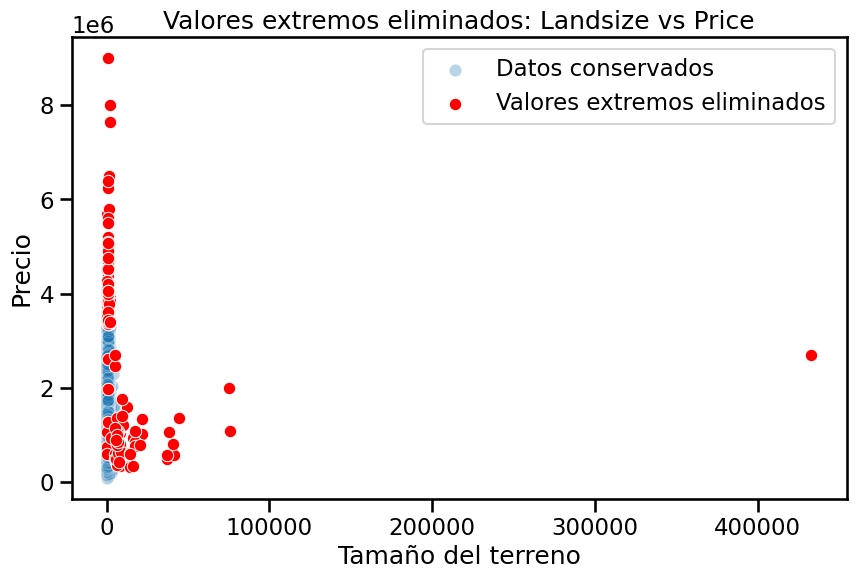

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=melb_df_limpio,
    x='Landsize',
    y='Price',
    alpha=0.3,
    label='Datos conservados'
)

sns.scatterplot(
    data=outliers,
    x='Landsize',
    y='Price',
    color='red',
    s=80,
    label='Valores extremos eliminados'
)

plt.title('Valores extremos eliminados: Landsize vs Price')
plt.xlabel('Tamaño del terreno')
plt.ylabel('Precio')
plt.legend()
plt.show()

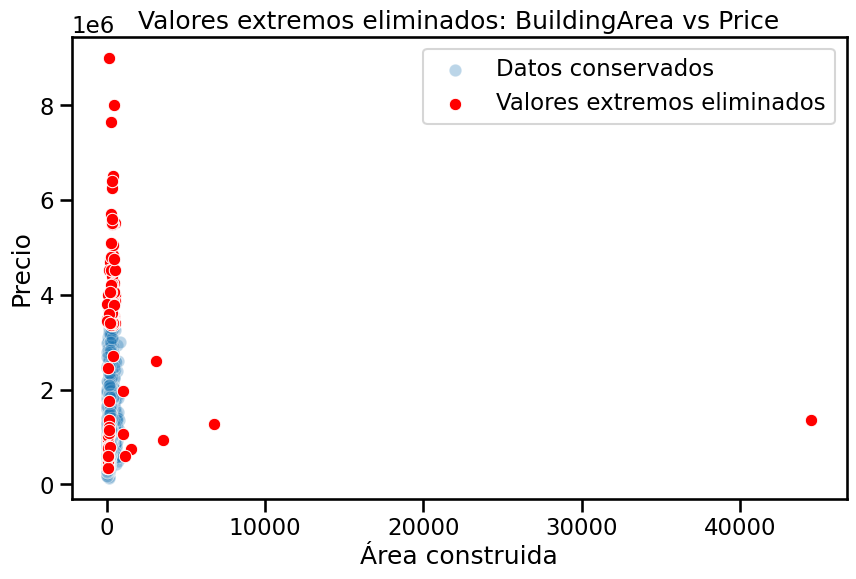

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=melb_df_limpio,
    x='BuildingArea',
    y='Price',
    alpha=0.3,
    label='Datos conservados'
)

sns.scatterplot(
    data=outliers,
    x='BuildingArea',
    y='Price',
    color='red',
    s=80,
    label='Valores extremos eliminados'
)

plt.title('Valores extremos eliminados: BuildingArea vs Price')
plt.xlabel('Área construida')
plt.ylabel('Precio')
plt.legend()
plt.show()

En síntesis, se aplicó un tratamiento moderado de valores extremos sobre las variables `Price`, `Landsize` y `BuildingArea`, ya que fueron las que mostraron mayor dispersión en el análisis exploratorio. El procedimiento permitió reducir la presencia de observaciones muy atípicas sin afectar sustancialmente el tamaño del dataset. La base resultante, `melb_df_limpio`, será utilizada en los pasos posteriores del ejercicio.

In [ ]:
criterios_outliers = pd.DataFrame({
    'criterio': [
        'Price superior al percentil 99',
        'Landsize superior a 5000 m²',
        'BuildingArea superior a 1000 m²'
    ],
    'cantidad_observaciones': [
        (melb_df_curado['Price'] > limite_precio).sum(),
        (melb_df_curado['Landsize'] > limite_terreno).sum(),
        (melb_df_curado['BuildingArea'] > limite_construccion).sum()
    ]
})

criterios_outliers

,criterio,cantidad_observaciones
0,Price superior al percentil 99,136
1,Landsize superior a 5000 m²,63
2,BuildingArea superior a 1000 m²,8


In [ ]:
# 6. Selección de variables de Airbnb y criterio de agregación

airbnb_df = pd.read_csv(ruta_airbnb)

print("Columnas disponibles en el dataset de Airbnb:")
display(airbnb_df.columns)

print("Primeras filas del dataset Airbnb:")
display(airbnb_df.head())

Columnas disponibles en el dataset de Airbnb:


Index(['zipcode', 'airbnb_price_mean', 'airbnb_record_count',
       'airbnb_weekly_price_mean', 'airbnb_monthly_price_mean'],
      dtype='object')

Primeras filas del dataset Airbnb:


,zipcode,airbnb_price_mean,airbnb_record_count,airbnb_weekly_price_mean,airbnb_monthly_price_mean
0,2010.0,40.000000,1,NaN,NaN
1,2134.0,50.000000,1,NaN,NaN
2,2582.0,104.000000,1,NaN,NaN
3,3000.0,150.504307,3367,918.738956,3407.204651
4,3001.0,132.500000,2,NaN,NaN


El archivo disponible ya se encuentra agregado por código postal y contiene, entre otras variables, `airbnb_price_mean`, `airbnb_weekly_price_mean`, `airbnb_monthly_price_mean` y `airbnb_record_count`. Si bien para variables de precios suele ser preferible utilizar la mediana, porque es menos sensible a valores extremos, en este caso el archivo disponible no contiene `airbnb_price_median`. Por ese motivo, se utiliza `airbnb_price_mean` como aproximación al nivel promedio de precios de Airbnb en cada zona.

También se conserva `airbnb_record_count`, ya que permite evaluar cuántos registros de Airbnb respaldan el cálculo de precios en cada zipcode. Esta variable será utilizada para filtrar zipcodes con muy pocas observaciones.

In [ ]:
# Seleccionamos variables relevantes del dataset Airbnb

airbnb_agrupado = airbnb_df[
    ['zipcode', 'airbnb_record_count', 'airbnb_price_mean']
].copy()

display(airbnb_agrupado.head())

,zipcode,airbnb_record_count,airbnb_price_mean
0,2010.0,1,40.000000
1,2134.0,1,50.000000
2,2582.0,1,104.000000
3,3000.0,3367,150.504307
4,3001.0,2,132.500000


In [ ]:
min_registros = 25

La combinación entre el dataset de propiedades de Melbourne y el dataset de Airbnb se realiza utilizando `Postcode` en Melbourne y `zipcode` en Airbnb. Antes de realizar la unión, se filtran los códigos postales de Airbnb para conservar únicamente aquellos con al menos 25 registros. Este umbral busca asegurar que el precio promedio incorporado esté basado en una cantidad mínima de observaciones y no en casos aislados.

Se utiliza un `left merge` tomando como base el dataset limpio de Melbourne, `melb_df_limpio`, para conservar todas las propiedades luego del tratamiento de outliers. Las variables provenientes de Airbnb se agregan cuando existe información disponible para el código postal correspondiente.

In [ ]:
# 7. Unión de datasets mediante zipcode

min_registros = 25

airbnb_relevante = airbnb_agrupado[
    airbnb_agrupado['airbnb_record_count'] >= min_registros
].copy()

print(f"Total de zipcodes en Airbnb: {airbnb_agrupado['zipcode'].nunique()}")
print(f"Zipcodes con al menos {min_registros} registros: {airbnb_relevante['zipcode'].nunique()}")

Total de zipcodes en Airbnb: 247
Zipcodes con al menos 25 registros: 128


In [ ]:
# 8. Merge entre Melbourne y Airbnb usando Postcode / zipcode

melb_df_enriquecido = pd.merge(
    melb_df_limpio,
    airbnb_relevante,
    how='left',
    left_on='Postcode',
    right_on='zipcode'
)

# Eliminamos zipcode porque duplica la información de Postcode
melb_df_enriquecido.drop(columns=['zipcode'], inplace=True)

display(
    melb_df_enriquecido[
        ['Suburb', 'Postcode', 'Price', 'airbnb_price_mean', 'airbnb_record_count']
    ].head()
)

,Suburb,Postcode,Price,airbnb_price_mean,airbnb_record_count
0,Abbotsford,3067.0,1480000.0,130.624031,258.0
1,Abbotsford,3067.0,1035000.0,130.624031,258.0
2,Abbotsford,3067.0,1465000.0,130.624031,258.0
3,Abbotsford,3067.0,850000.0,130.624031,258.0
4,Abbotsford,3067.0,1600000.0,130.624031,258.0


In [ ]:
# Validaciones post-merge

assert len(melb_df_enriquecido) == len(melb_df_limpio), \
    "El merge modificó la cantidad de filas del dataset base."

assert melb_df_enriquecido['Price'].isna().sum() == melb_df_limpio['Price'].isna().sum(), \
    "El merge modificó inesperadamente la cantidad de nulos en Price."

assert (melb_df_enriquecido['airbnb_price_mean'].dropna() >= 0).all(), \
    "Hay valores negativos en airbnb_price_mean."

assert (melb_df_enriquecido['airbnb_record_count'].dropna() >= min_registros).all(), \
    "Hay zipcodes agregados con menos registros que el mínimo definido."

propiedades_con_airbnb = melb_df_enriquecido['airbnb_price_mean'].notna().sum()
total_propiedades = len(melb_df_enriquecido)
porcentaje_match = propiedades_con_airbnb / total_propiedades * 100

print("Validaciones post-merge superadas.")
print(f"Total de propiedades limpias de Melbourne: {total_propiedades}")
print(f"Propiedades con información de Airbnb agregada: {propiedades_con_airbnb}")
print(f"Porcentaje de propiedades con información Airbnb: {porcentaje_match:.2f}%")

Validaciones post-merge superadas.
Total de propiedades limpias de Melbourne: 13374
Propiedades con información de Airbnb agregada: 11552
Porcentaje de propiedades con información Airbnb: 86.38%


Luego del merge, se valida que la cantidad de filas del dataset de Melbourne no haya cambiado. Esta verificación es importante porque un merge mal definido podría duplicar propiedades o eliminar registros. También se controla que la variable objetivo `Price` no haya sido alterada por la operación.

Las propiedades cuyo `Postcode` no se encuentra en el dataset de Airbnb filtrado quedan con valores faltantes en las variables agregadas. Esto es esperable, ya que no todos los códigos postales tienen información suficiente de Airbnb para ser incorporados.

El enunciado propone graficar `zipcode` contra `airbnb_price_median`. Sin embargo, el archivo disponible no contiene la mediana sino el precio promedio (`airbnb_price_mean`). Por este motivo, se grafica el precio promedio de Airbnb por zipcode, utilizando además el tamaño de los puntos para representar la cantidad de registros disponibles en cada código postal.

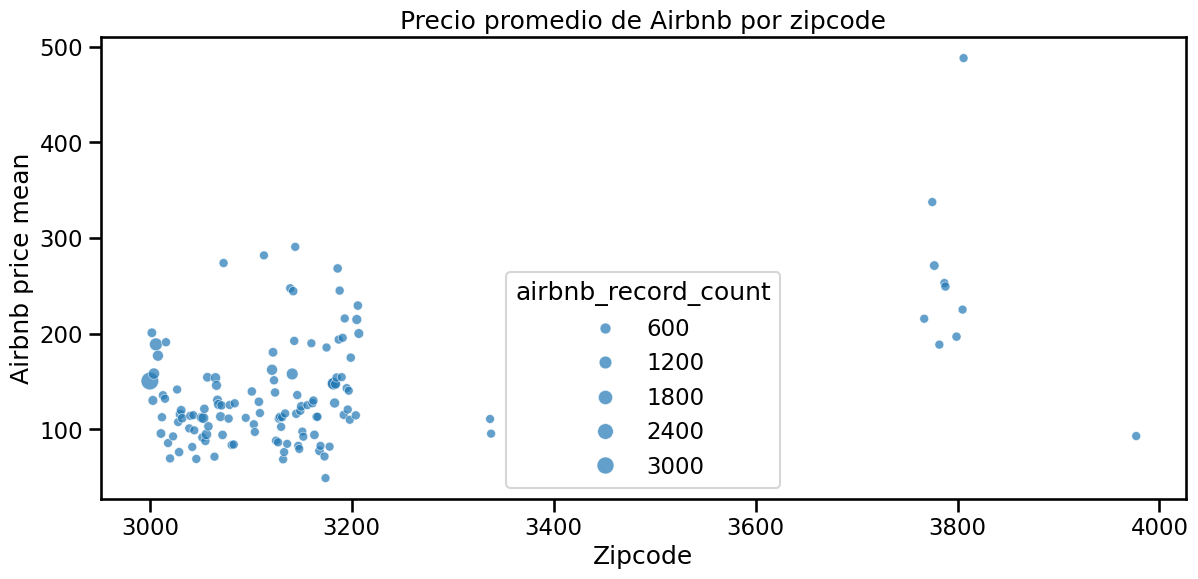

In [ ]:
# 9. Visualización de precios de Airbnb por zipcode

plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=airbnb_relevante,
    x='zipcode',
    y='airbnb_price_mean',
    size='airbnb_record_count',
    alpha=0.7,
    legend=True
)

plt.title('Precio promedio de Airbnb por zipcode')
plt.xlabel('Zipcode')
plt.ylabel('Airbnb price mean')
plt.show()

El gráfico permite observar diferencias en el precio promedio de Airbnb entre códigos postales. Los puntos de mayor tamaño representan zipcodes con mayor cantidad de registros, por lo que sus promedios se encuentran respaldados por más observaciones. Esta información puede ser útil como proxy del atractivo turístico o comercial de una zona, lo cual podría relacionarse indirectamente con el valor de las propiedades.

In [ ]:
# 10. Variables alternativas para combinar datasets

Además de `zipcode`, podrían considerarse otras variables para combinar el dataset de propiedades de Melbourne con información proveniente de Airbnb u otras fuentes externas.

Una primera alternativa es utilizar el barrio o suburbio (`Suburb`). Esta variable puede ser adecuada porque representa una unidad territorial reconocible en el mercado inmobiliario y suele estar asociada a diferencias relevantes de precio. Sin embargo, su uso requiere cuidado, ya que los nombres de barrios pueden diferir entre datasets por abreviaturas, errores de escritura, diferencias de capitalización o criterios administrativos distintos. Para utilizarla correctamente, sería conveniente construir una tabla de equivalencias validada por expertos.

Una segunda alternativa es utilizar direcciones o zonas aproximadas. Esta opción podría ser útil si ambos datasets contaran con información textual de ubicación suficientemente detallada. No obstante, presenta dificultades porque las direcciones pueden estar incompletas, normalizadas de forma distinta o no coincidir exactamente entre fuentes. Además, usar direcciones exactas podría introducir problemas de privacidad o excesiva granularidad.

Una tercera alternativa sería utilizar variables territoriales más amplias, como `Regionname` o `CouncilArea`, cuando estén disponibles en ambos datasets. Estas variables pueden servir para hacer agregaciones geográficas generales, aunque son menos precisas que `zipcode` o `Suburb`, porque pueden agrupar zonas heterogéneas con comportamientos de precio diferentes.

Si tuvieramos que entrevistar a un experto inmobiliario para mapear barrios entre datasets, le haría las siguientes preguntas:

1. ¿Qué barrios o suburbios considera comercialmente equivalentes aunque aparezcan con nombres distintos en distintas fuentes de datos?
2. ¿Existen zonas dentro de un mismo `zipcode` o suburbio que tengan comportamientos de precio muy diferentes y que no deberían analizarse juntas?
3. ¿Qué variables de entorno suelen explicar mejor las diferencias de precio entre propiedades similares, por ejemplo cercanía a transporte, colegios, parques, zonas comerciales, seguridad o accesibilidad?

In [ ]:
# 11.  Uso potencial de coordenadas geoespaciales

Si las coordenadas geoespaciales estuvieran disponibles en ambos datasets, podrían utilizarse para construir variables de entorno más precisas que las basadas únicamente en `zipcode`. En lugar de asociar cada propiedad al promedio de Airbnb de su código postal, se podría calcular el precio promedio o mediano de los alojamientos Airbnb ubicados dentro de un radio determinado, por ejemplo 500 metros o 1 kilómetro alrededor de cada propiedad.

Otra alternativa sería identificar los `n` alojamientos Airbnb más cercanos a cada propiedad y calcular estadísticas agregadas sobre ellos, como precio promedio, precio mediano, cantidad de alojamientos cercanos o distancia al Airbnb más próximo. Esto permitiría capturar mejor el entorno inmediato de cada propiedad, especialmente en zonas donde un mismo `zipcode` contiene áreas con comportamientos de precio muy diferentes.

Este enfoque sería más preciso que una unión por código postal, aunque requeriría mayor procesamiento geoespacial y la definición de criterios metodológicos, como el radio de búsqueda o la cantidad de vecinos cercanos a considerar.

In [ ]:
# Información adicional deseable para predecir el precio

Para mejorar la predicción del precio de una propiedad sería útil contar con información adicional que no está disponible en el dataset. Por ejemplo, estado de conservación, remodelaciones recientes, calidad constructiva, amenities, orientación, nivel de ruido, piso en caso de departamentos, eficiencia energética, cercanía a transporte público, colegios, parques, centros comerciales y percepción de seguridad del entorno.

También podrían ser útiles fotografías o descripciones textuales de las propiedades, ya que capturan atributos cualitativos difíciles de representar mediante variables estructuradas. Finalmente, variables macroeconómicas o de mercado, como tasas de interés, evolución temporal de precios inmobiliarios o condiciones de demanda, podrían mejorar la capacidad predictiva del modelo.



---



## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

In [ ]:
# Verificamos las dimensiones y columnas del dataset final

print("Dimensiones del dataset final:")
print(melb_df_enriquecido.shape)

print("\nColumnas del dataset final:")
print(melb_df_enriquecido.columns.tolist())

display(melb_df_enriquecido.head())

Dimensiones del dataset final:
(13374, 16)

Columnas del dataset final:
['Suburb', 'Rooms', 'Type', 'Price', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Regionname', 'airbnb_record_count', 'airbnb_price_mean']


,Suburb,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,airbnb_record_count,airbnb_price_mean
0,Abbotsford,2,h,1480000.0,2.5,3067.0,1.0,1.0,202.0,NaN,NaN,-37.7996,144.9984,Northern Metropolitan,258.0,130.624031
1,Abbotsford,2,h,1035000.0,2.5,3067.0,1.0,0.0,156.0,79.0,1900.0,-37.8079,144.9934,Northern Metropolitan,258.0,130.624031
2,Abbotsford,3,h,1465000.0,2.5,3067.0,2.0,0.0,134.0,150.0,1900.0,-37.8093,144.9944,Northern Metropolitan,258.0,130.624031
3,Abbotsford,3,h,850000.0,2.5,3067.0,2.0,1.0,94.0,NaN,NaN,-37.7969,144.9969,Northern Metropolitan,258.0,130.624031
4,Abbotsford,4,h,1600000.0,2.5,3067.0,1.0,2.0,120.0,142.0,2014.0,-37.8072,144.9941,Northern Metropolitan,258.0,130.624031


El DataFrame final utilizado es `melb_df_enriquecido`, ya que contiene la base limpia de Melbourne y las variables agregadas provenientes de Airbnb.

In [ ]:
# Validaciones básicas antes de guardar el dataset final

assert len(melb_df_enriquecido) == len(melb_df_limpio), \
    "El dataset final no conserva la cantidad de filas del dataset limpio."

assert 'Price' in melb_df_enriquecido.columns, \
    "La variable objetivo Price no se encuentra en el dataset final."

assert 'airbnb_price_mean' in melb_df_enriquecido.columns, \
    "La variable airbnb_price_mean no se encuentra en el dataset final."

assert 'airbnb_record_count' in melb_df_enriquecido.columns, \
    "La variable airbnb_record_count no se encuentra en el dataset final."

assert melb_df_enriquecido['Price'].notna().all(), \
    "Existen valores faltantes en la variable objetivo Price."

print("Validaciones previas superadas.")

Validaciones previas superadas.


In [ ]:
# Guardamos el dataset final curado

nombre_archivo_final = "melbourne_airbnb_curado.csv"

melb_df_enriquecido.to_csv(nombre_archivo_final, index=False)

print(f"Dataset final guardado como: {nombre_archivo_final}")

Dataset final guardado como: melbourne_airbnb_curado.csv


In [ ]:
# Leemos nuevamente el archivo guardado para validar que se generó correctamente

df_final_validacion = pd.read_csv(nombre_archivo_final)

print("Dimensiones del archivo guardado:")
print(df_final_validacion.shape)

display(df_final_validacion.head())

Dimensiones del archivo guardado:
(13374, 16)


,Suburb,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,airbnb_record_count,airbnb_price_mean
0,Abbotsford,2,h,1480000.0,2.5,3067.0,1.0,1.0,202.0,NaN,NaN,-37.7996,144.9984,Northern Metropolitan,258.0,130.624031
1,Abbotsford,2,h,1035000.0,2.5,3067.0,1.0,0.0,156.0,79.0,1900.0,-37.8079,144.9934,Northern Metropolitan,258.0,130.624031
2,Abbotsford,3,h,1465000.0,2.5,3067.0,2.0,0.0,134.0,150.0,1900.0,-37.8093,144.9944,Northern Metropolitan,258.0,130.624031
3,Abbotsford,3,h,850000.0,2.5,3067.0,2.0,1.0,94.0,NaN,NaN,-37.7969,144.9969,Northern Metropolitan,258.0,130.624031
4,Abbotsford,4,h,1600000.0,2.5,3067.0,1.0,2.0,120.0,142.0,2014.0,-37.8072,144.9941,Northern Metropolitan,258.0,130.624031


In [ ]:
assert df_final_validacion.shape == melb_df_enriquecido.shape, \
    "El archivo guardado no conserva las mismas dimensiones que el dataset final."

print("Archivo final validado correctamente.")

Archivo final validado correctamente.


El archivo `melbourne_airbnb_curado.csv` contiene el dataset final generado a partir de las transformaciones realizadas previamente. Este conjunto de datos conserva las propiedades limpias de Melbourne, excluye los valores extremos definidos en el análisis exploratorio e incorpora información agregada de Airbnb por código postal.

Este dataset queda disponible para ser utilizado en etapas posteriores de análisis o modelado predictivo del precio de propiedades.

## Ejercicios opcionales:

El notebook `02.2 ETLs-DAGs.ipynb` tiene un esqueleto de referencia para guiarse.

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)

3. Bonus: embeddings y búsqueda semántica con descripciones de AirBnB.
   - Usar `sentence-transformers` para codificar descripciones textuales de propiedades.
   - Tomar un subconjunto chico de descripciones, calcular embeddings y encontrar el par más similar con similitud coseno.
   - Reflexionar: ¿por qué este resultado no se puede lograr con `LIKE '%keyword%'` en SQL? ¿Qué pasa si dos propiedades son similares pero usan palabras distintas? ¿Qué representan los 384 números del embedding?

4. Bonus: curación asistida por IA sobre `CouncilArea`.
   - Tomar los valores únicos de `CouncilArea` y pedirle a un modelo de lenguaje que sugiera posibles inconsistencias, duplicados por capitalización o spelling y agrupaciones razonables.
   - Proponer una estandarización preliminar y luego validar manualmente si el mapeo tiene sentido.
   - Reflexionar: ¿cuándo confiarías en este resultado sin revisarlo? ¿Qué pasa si el modelo inventa un mapeo incorrecto? ¿Cómo validarías el resultado si la columna tuviera miles de valores únicos?


5. Bonus: curación asistida por IA sobre `CouncilArea`.
   - Tomar los valores únicos de `CouncilArea` y pedirle a un modelo de lenguaje que sugiera posibles inconsistencias, duplicados por capitalización o spelling y agrupaciones razonables.
   - Proponer una estandarización preliminar y luego validar manualmente si el mapeo tiene sentido.
   - Reflexionar: ¿cuándo confiarías en este resultado sin revisarlo? ¿Qué pasa si el modelo inventa un mapeo incorrecto? ¿Cómo validarías el resultado si la columna tuviera miles de valores únicos?

Ejemplo conceptual:


In [ ]:
!pip install anthropic

In [ ]:
import anthropic
import json

client = anthropic.Anthropic()

# Valores únicos con posibles inconsistencias
council_values = melb_df['CouncilArea'].dropna().unique().tolist()

message = client.messages.create(
    model="claude-opus-4-7",
    max_tokens=1024,
    messages=[{
        "role": "user",
        "content": f"""Estos son los valores únicos de la columna CouncilArea en un dataset de propiedades de Melbourne:
{council_values}

Identificá: (1) duplicados con distinta capitalización o spelling,
 (2) valores que parecen errores, (3) valores que podrían agruparse.
Respondé en JSON con la estructura: {{"estandarizado": {{"valor_original": "valor_correcto"}}}}"""
    }]
)

mapping = json.loads(message.content[0].text)
melb_df['CouncilArea_clean'] = melb_df['CouncilArea'].map(
    mapping.get('estandarizado', {})
).fillna(melb_df['CouncilArea'])
